In [1]:
#impoting necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin

# where you want the data to be taken from and where you want to plots to go
InputPath = 'DataFolder'
OutputPath = 'PlotsFolder/'



def Power_And_Irradiance_MeanMinMax(year, day):
    '''
    This function takes in the year and the day, then it returns a dictionary with mean min max values for
    the powers and the irradiances for those days
    '''
    #Take input for year(YY) and day of year(DDD)
    
    # year = 2025
    # day = 345
    
    input_1  = year
    input_2  = day
    
    baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
    year = input_1 # last two digits of the year (from input_1)
    
    Area = 2.0 #m**2
    
    try:
        # -----------------NOAA-----------------------------------
        NOAA = [] #list to hold dataframes
        for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
            iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
            filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
            print(filename) #print the filename being accessed
        
            try:
                file = urllib.request.urlopen(filename)
                data = file.read().decode('utf-8').split('\n') #read the file and split into lines
                #convert data to dataframe
                df = pd.DataFrame([row.split() for row in data[2:]])
                # print(dt)
                NOAA.append(df) #append dataframe to list
            except urllib.error.HTTPError:
                print(f"{filename} file not found") #print error if file not found
        
        # print('dir Irradiance data time correction')
        '''Direct Irradiance'''
        #define the direct irradiance and diffuse irradiance data with time correction for NZDT
        NOAAdir_ir_1 = NOAA[0][12]
        NOAAdir_ir_2 = NOAA[1][12]
        NOAAtemp = NOAA[0][38]
        # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
        # print(f'NOAAtemp: {NOAAtemp}')
        # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
        # concatenate the two days data with time correction
        NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
        #convert this to float
        NZDTdir_ir = NZDTdir_ir.astype(float)
        #remove nan values from NZDTdir_ir 
        NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
        # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
        # NZDTdir_ir = NZDTdir_ir.astype(float)
        # print(len(NZDTdir_ir))
        
        # print(NZDTdir_ir)
        
        # print('diff Irradiance data time correction')
        ''' Diffuse irradiance'''
        #diffuse irradiance
        NOAAdiff_ir_1 = NOAA[0][14]
        NOAAdiff_ir_2 = NOAA[1][14]
        
        # concatenate the two days data with time correction
        NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
        NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
        
        #remove nan values from NZDTdiff_ir 
        NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
        # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
        # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
        
        ''' Upwelling irradiance'''
        #upwelling irradiance
        NOAAup_ir_1 = NOAA[0][10] 
        NOAAup_ir_2 = NOAA[1][10]
        NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
        NZDTup_ir = NZDTup_ir.astype(float)
        #remove nan values from NZDTup_ir 
        NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
        # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
        # NZDTup_ir = NZDTup_ir.astype(float)

        '''Solar Zenith Angle'''
        NOAA_Zenith_1 = NOAA[0][7] 
        NOAA_Zenith_2 = NOAA[1][7]
        NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
        NZDT_Zenith = NZDT_Zenith.astype(float)
        #remove nan values from NZDTup_ir 
        NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
        
        
        '''Time List'''
        # print(NZDTdiff_ir)
        # Create a range of timestamps with a frequency of 1 minute ('min')
        times_list = pd.date_range("00:00:00", periods=1440, freq="min")
        
        # Format as HH:MM:SS strings
        NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
        NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
        NOAA_time = NOAA_time.astype(str).str.split().str[-1]
        
        #time list for the device data
        times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
        
        # Format as HH:MM:SS strings
        device_time = times_list_device.strftime("%H:%M:%S").tolist()    
        device_time = pd.to_timedelta(pd.Series(device_time))
        device_time = device_time.astype(str).str.split().str[-1]
        IrrMeanMinMax = [[np.mean(NZDTdir_ir), np.min(NZDTdir_ir), np.max(NZDTdir_ir)], [np.mean(NZDTdiff_ir), np.min(NZDTdiff_ir), np.max(NZDTdiff_ir)], [np.mean(NZDTup_ir), np.min(NZDTup_ir), np.max(NZDTup_ir)]]
        
        Irradiance_Direct_mean = np.mean(NZDTdir_ir)
        Irradiance_Direct_min = np.min(NZDTdir_ir)
        Irradiance_Direct_max = np.max(NZDTdir_ir)

        Irradiance_Diffuse_mean = np.mean(NZDTdiff_ir)
        Irradiance_Diffuse_min = np.min(NZDTdiff_ir)
        Irradiance_Diffuse_max = np.max(NZDTdiff_ir)

        Irradiance_Upwelling_mean = np.mean(NZDTup_ir)
        Irradiance_Upwelling_min = np.min(NZDTup_ir)
        Irradiance_Upwelling_max = np.max(NZDTup_ir)

        Zenith_Angle_mean = np.mean(NZDT_Zenith)
        Zenith_Angle_min = np.min(NZDT_Zenith)
        Zenith_Angle_max = np.max(NZDT_Zenith)
        
    except FileNotFoundError:
        IrrMeanMinMax = [[np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan]]

        Irradiance_Direct_mean = np.nan
        Irradiance_Direct_min = np.nan
        Irradiance_Direct_max = np.nan

        Irradiance_Diffuse_mean = np.nan
        Irradiance_Diffuse_min = np.nan
        Irradiance_Diffuse_max = np.nan

        Irradiance_Upwelling_mean = np.nan
        Irradiance_Upwelling_min = np.nan
        Irradiance_Upwelling_max = np.nan

        Zenith_Angle_mean = np.nan
        Zenith_Angle_min = np.nan
        Zenith_Angle_max = np.nan
        
    except IndexError:
        IrrMeanMinMax = [[np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan], [np.nan,np.nan,np.nan]]

        Irradiance_Direct_mean = np.nan
        Irradiance_Direct_min = np.nan
        Irradiance_Direct_max = np.nan

        Irradiance_Diffuse_mean = np.nan
        Irradiance_Diffuse_min = np.nan
        Irradiance_Diffuse_max = np.nan

        Irradiance_Upwelling_mean = np.nan
        Irradiance_Upwelling_min = np.nan
        Irradiance_Upwelling_max = np.nan

        Zenith_Angle_mean = np.nan
        Zenith_Angle_min = np.nan
        Zenith_Angle_max = np.nan
        
    try:
        # --------REAL PANEL DATA-------------
        #Read the CSV files based on user input
        
        file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{'{0:03d}'.format(input_2)}.csv",delimiter=',')
        file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{'{0:03d}'.format(input_2)}.csv",delimiter=',')
        

        # Rename the Device ID column to voltage and Voltage to Current
        file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
        file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
        
        # Each file has the data for more than just the day it is. We want to remove this extra dataS
        
        def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
            # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
        
            # You can skip splitting the string and go directly to parsing:
            date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
            
            # 29 # return the day of the year (%j) as an integer
            # The strftime method returns a string, so we convert it to an integer.
            return int(date_object.strftime('%j'))
        # print(f'DEBUG: {input_2}')
        date = file_101['Date']
        NumberDate = date.apply(date2num)
        mask_to_keep =  NumberDate <= int(input_2)
        file_101 = file_101[mask_to_keep]
        # print(f'DEBUG: {mask_to_keep}')
        # print(f'DEBUG: {NumberDate}')
        
        date = file_103['Date']
        NumberDate = date.apply(date2num)
        mask_to_keep = NumberDate <= int(input_2)
        file_103 = file_103[mask_to_keep]
        
        #Extract time, voltage and current data
        
        time_101 = file_101['Time']
        voltage_101 = file_101['V'] 
        current_101 = file_101['A'] 
        
        time_103 = file_103['Time']
        voltage_103 = file_103['V'] 
        current_103 = file_103['A'] 
        
        power_101 = voltage_101 * current_101
        power_103 = voltage_103 * current_103
        # -----------------------------
        print(f'File Loaded {day}')
        PowerMeanMinMax = [[np.nanmean(power_101), np.min(power_101), np.max(power_101)],[np.nanmean(power_103), np.min(power_103), np.max(power_103)]]

        Power_101_mean = np.nanmean(power_101)
        Power_101_min = np.min(power_101)
        Power_101_max = np.max(power_101)
        Power_101_sd = np.std(power_101)

        Power_103_mean = np.nanmean(power_101)
        Power_103_min = np.min(power_101)
        Power_103_max = np.max(power_101)
        
    except FileNotFoundError:
        print('File Not Loaded')
        PowerMeanMinMax = [[np.nan, np.nan, np.nan], [np.nan, np.nan, np.nan]]

        Power_101_mean = np.nan
        Power_101_min = np.nan
        Power_101_max = np.nan
        Power_101_sd = np.nan
        

        Power_103_mean = np.nan
        Power_103_min = np.nan
        Power_103_max = np.nan
        
    except KeyError:
        print('File Not Loaded')
        PowerMeanMinMax = [[np.nan, np.nan, np.nan], [np.nan, np.nan, np.nan]]

        Power_101_mean = np.nan
        Power_101_min = np.nan
        Power_101_max = np.nan
        Power_101_sd = np.nan
        

        Power_103_mean = np.nan
        Power_103_min = np.nan
        Power_103_max = np.nan
        
    # except 
    ValuesToReturn = {'Irradiance_Direct_mean':Irradiance_Direct_mean,
                     'Irradiance_Direct_min':Irradiance_Direct_min,
                     'Irradiance_Direct_max':Irradiance_Direct_max,
                     'Irradiance_Diffuse_mean':Irradiance_Diffuse_mean,
                     'Irradiance_Diffuse_min':Irradiance_Diffuse_min,
                     'Irradiance_Diffuse_max':Irradiance_Diffuse_max,
                     'Irradiance_Upwelling_mean':Irradiance_Upwelling_mean,
                     'Irradaince_Upwelling_min':Irradiance_Upwelling_min,
                     'Irradaince_Upwelling_max':Irradiance_Upwelling_max,
                     'Power_101_mean':Power_101_mean,
                     'Power_101_min':Power_101_min,
                     'Power_101_max':Power_101_max,
                      'Power_101_sd':Power_101_sd,
                     'Power_103_mean':Power_103_mean,
                     'Power_103_min':Power_103_min,
                     'Power_103_max':Power_103_max,
                     'Zenith_Angle_mean':Zenith_Angle_mean,
                     'Zenith_Angle_min':Zenith_Angle_min,
                     'Zenith_Angle_max':Zenith_Angle_max}
    return ValuesToReturn



In [2]:
Day_Range2025 = np.arange(334, 366, 1)
# Irradiance_Triplet_2025 = [] # list of (Direct, Diffuse, Upwelling) Irradiances [mean] for each day in 2025
# Power2025 = [] # list of (101, 103) power means for each day in 2025 
# # for 2025
# for day in Day_Range2025:
#     PowerMeanDay = Power_And_Irradiance_MeanMinMax(25,day)[0]
#     IrradianceMeanDay = Power_And_Irradiance_MeanMinMax(25,day)[1]
#     Power2025.append(PowerMeanDay)
#     Irradiance_Triplet_2025.append(IrradianceMeanDay)
# print(Irradiance_Triplet_2025)
# print()
# print(Power2025)

# Direct_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,0,0]
# Diffuse_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,1,0]
# Upwelling_Irradiance_Mean_2025 = np.array(Irradiance_Triplet_2025)[:,2,0]

# print(Direct_Irradiance_2025)
# # plt.show()
# Power101_2025 = np.array(Power2025)[:,0,0]
Direct_Irradiance_mean_2025 = []
Direct_Irradiance_min_2025 = []
Direct_Irradiance_max_2025 = []

Diffuse_Irradiance_mean_2025 = []
Upwelling_Irradiance_mean_2025 = []

Power_101_2025_mean = []
Power_101_2025_min = []
Power_101_2025_max = []
Power_101_2025_sd = []

Zenith_Angle_2025_mean = []
Zenith_Angle_2025_min = []
Zenith_Angle_2025_max = []

for day in Day_Range2025:
    InfoDict = Power_And_Irradiance_MeanMinMax(25, day)
    
    Direct_Irradiance_mean_2025.append(InfoDict['Irradiance_Direct_mean'])
    Direct_Irradiance_min_2025.append(InfoDict['Irradiance_Direct_min'])
    Direct_Irradiance_max_2025.append(InfoDict['Irradiance_Direct_max'])
    
    Diffuse_Irradiance_mean_2025.append(InfoDict['Irradiance_Diffuse_mean'])
    Upwelling_Irradiance_mean_2025.append(InfoDict['Irradiance_Upwelling_mean'])

    Power_101_2025_mean.append(InfoDict['Power_101_mean'])
    Power_101_2025_min.append(InfoDict['Power_101_min'])
    Power_101_2025_max.append(InfoDict['Power_101_max'])
    Power_101_2025_sd.append(InfoDict['Power_101_sd'])

    Zenith_Angle_2025_mean.append(InfoDict['Zenith_Angle_mean'])
    Zenith_Angle_2025_min.append(InfoDict['Zenith_Angle_min'])
    Zenith_Angle_2025_max.append(InfoDict['Zenith_Angle_max'])


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25333.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
File Loaded 334
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
File Not Loaded
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
File Loaded 337
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
File Loaded 338
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25338.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25339.dat
File Loaded 339
https://gml.noaa.gov/aftp/data/radiation

[334 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351
 352 353 354 355 356 357 358 359 360 361 362 363 364 365]
[np.float64(21.67777083333334), np.float64(21.836326388888892), np.float64(21.988145833333334), np.float64(22.132798611111113), np.float64(22.27054166666666), np.float64(22.400888888888886), np.float64(22.52424305555556), np.float64(22.640381944444442), np.float64(22.74898611111111), np.float64(22.850361111111113), np.float64(22.94419444444445), np.float64(23.03047916666665), np.float64(23.109395833333338), np.float64(23.180409722222223), np.float64(23.24404861111111), np.float64(23.300111111111093), np.float64(23.34813194444446), np.float64(23.38850694444443), np.float64(23.420854166666672), np.float64(23.446298611111118), np.float64(23.463458333333335), np.float64(23.472201388888905), np.float64(23.47086805555557), np.float64(23.46854166666668), np.float64(23.45261111111111), np.float64(23.430111111111117), np.float64(23.40035416666666), np.float64(23.362

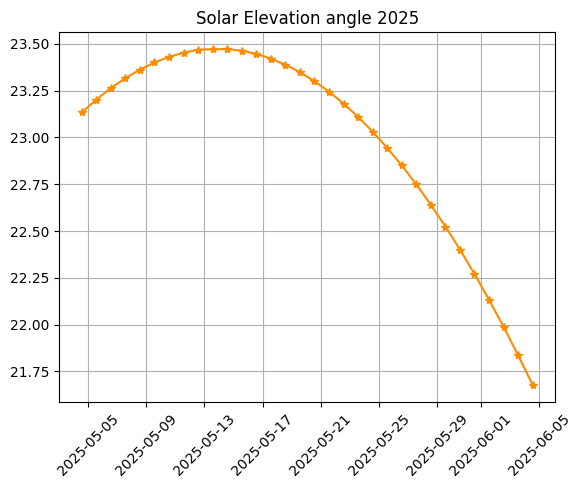

In [6]:
Solar_Elevation_Angle_2025_mean = []
Solar_Elevation_Angle_2025_min = []
Solar_Elevation_Angle_2025_max = []

for i in Zenith_Angle_2025_mean:
    Solar_Elevation_Angle_2025_mean.append(90-i)
for i in Zenith_Angle_2025_min:
    Solar_Elevation_Angle_2025_min.append(90-i)
for i in Zenith_Angle_2025_max:
    Solar_Elevation_Angle_2025_max.append(90-i)


import datetime

a = datetime.datetime.today()
numdays = Day_Range2025[-1]
dateList = []
for x in range (Day_Range2025[0], numdays+1):
    dateList.append(a - datetime.timedelta(days = x))
# print(dateList)
print(Day_Range2025)
print(Solar_Elevation_Angle_2025_mean)
plt.plot(dateList, Solar_Elevation_Angle_2025_mean, marker = '*', color = 'darkorange')
plt.title('Solar Elevation angle 2025')
# plt.fill_between(dateList, Solar_Elevation_Angle_2025_min, Solar_Elevation_Angle_2025_max, alpha = .3, color = 'darkorange')
plt.grid('on')
plt.xticks(rotation = 45)
plt.show()

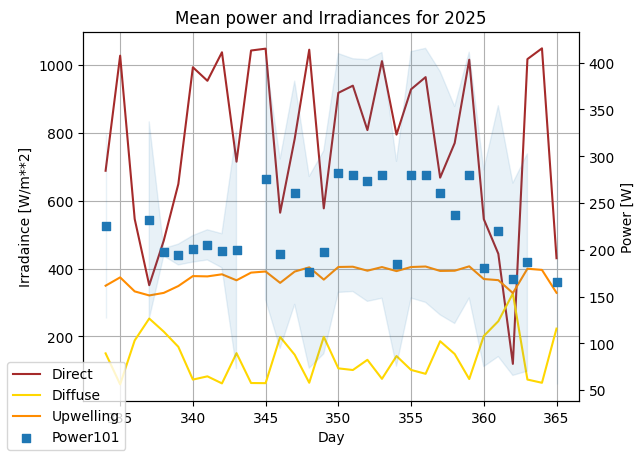

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Day_Range2025, Direct_Irradiance_mean_2025, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Day_Range2025, Diffuse_Irradiance_mean_2025, label = 'Diffuse', color = 'gold')
ax.plot(Day_Range2025, Upwelling_Irradiance_mean_2025, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Day_Range2025,Power_101_2025_mean, label = 'Power101', color = 'tab:blue', marker = 's')
# ax2.fill_between(Day_Range2025, Power_101_2025_min, Power_101_2025_max, color = 'tab:blue', alpha = .1)
ax2.fill_between(Day_Range2025, np.array(Power_101_2025_mean)-np.array(Power_101_2025_sd),np.array(Power_101_2025_mean)+np.array(Power_101_2025_sd) , color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Day')
ax.set_title(f'Mean power and Irradiances for {2025}')
fig.legend(loc = 'lower left')
ax.grid('on')
plt.show()
# print(f'len(Direct_Irradiance_2025): {len(Direct_Irradiance_2025)}')
# print(f'len(Diffuse_Irradiance_2025): {len(Diffuse_Irradiance_2025)}')
# print(f'len(Upwelling_Irradiance_2025): {len(Upwelling_Irradiance_2025)}')
# print(f'len(Power101_2025): {len(Power101_2025)}')

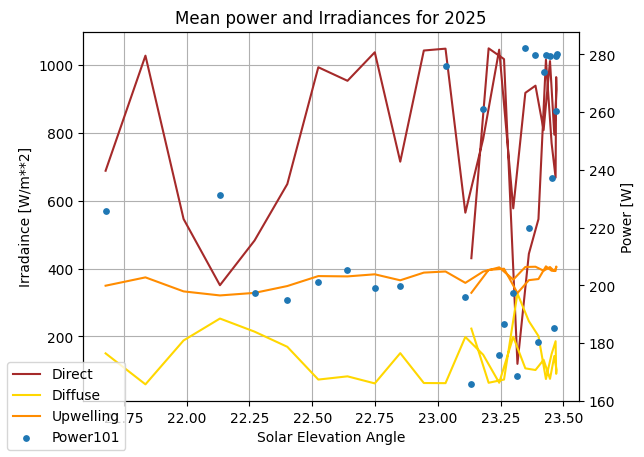

In [8]:
Solar_Elevation_Angle_2025_mean = []
for i in Zenith_Angle_2025_mean:
    Solar_Elevation_Angle_2025_mean.append(90-i)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Solar_Elevation_Angle_2025_mean, Direct_Irradiance_mean_2025, label = 'Direct', color = 'brown')
# ax.fill_between(Day_Range2025, Direct_Irradiance_min_2025, Direct_Irradiance_max_2025, color = 'brown', alpha = .1)

ax.plot(Solar_Elevation_Angle_2025_mean, Diffuse_Irradiance_mean_2025, label = 'Diffuse', color = 'gold')
ax.plot(Solar_Elevation_Angle_2025_mean, Upwelling_Irradiance_mean_2025, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.scatter(Solar_Elevation_Angle_2025_mean,Power_101_2025_mean, label = 'Power101', color = 'tab:blue', marker = 'o', s = 15)
# ax2.fill_between(Day_Range2025, Power_101_2025_mean - Power_101_2025_sd, Power_101_2025_mean + Power_101_2025_sd, color = 'tab:blue', alpha = .1)

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Solar Elevation Angle')
ax.set_title(f'Mean power and Irradiances for {2025}')
# ax.set_xscale('log')
fig.legend(loc = 'lower left')
ax.grid('on')
plt.show()

In [ ]:
plt.hist(Power101_2025, bins = 20)
plt.show()
plt.hist(Direct_Irradiance_2025, bins = 50)
plt.show()

In [ ]:
Day_Range2026 = np.arange(1, 27, 1)
Irradiance_Triplet_2026 = [] # list of (Direct, Diffuse, Upwelling) Irradiances [mean] for each day in 2025
Power2026 = [] # list of (101, 103) power means for each day in 2026 
# for 2026
for day in Day_Range2026:
    PowerMeanDay = Power_And_Irradiance_Mean(26,day)[0]
    IrradianceMeanDay = Power_And_Irradiance_Mean(26,day)[1]
    Power2026.append(PowerMeanDay)
    Irradiance_Triplet_2026.append(IrradianceMeanDay)
print(Irradiance_Triplet_2026)
print()
print(Power2026)

In [ ]:
Direct_Irradiance_2026 = np.array(Irradiance_Triplet_2026)[:,0]
Diffuse_Irradiance_2026 = np.array(Irradiance_Triplet_2026)[:,1]
Upwelling_Irradiance_2026 = np.array(Irradiance_Triplet_2026)[:,2]

print(Direct_Irradiance_2026)
# plt.show()
Power101_2026 = np.array(Power2026)[:,0]



fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Day_Range2026, Direct_Irradiance_2026, label = 'Direct', color = 'brown')
ax.plot(Day_Range2026, Diffuse_Irradiance_2026, label = 'Diffuse', color = 'gold')
ax.plot(Day_Range2026, Upwelling_Irradiance_2026, label = 'Upwelling', color = 'darkorange')

ax2 = ax.twinx()
ax2.plot(Day_Range2026,Power101_2026, label = 'Power101', color = 'tab:blue', linestyle = '--', marker = 's')

ax.set_ylabel('Irradaince [W/m**2]')
ax2.set_ylabel('Power [W]')
ax.set_xlabel('Day')
ax.set_title(f'Mean power and Irradiances for {2026}')
fig.legend(loc = 'lower left')
ax.grid('on')
plt.show()
print(f'len(Direct_Irradiance_2026): {len(Direct_Irradiance_2026)}')
print(f'len(Diffuse_Irradiance_2026): {len(Diffuse_Irradiance_2026)}')
print(f'len(Upwelling_Irradiance_2026): {len(Upwelling_Irradiance_2026)}')
print(f'len(Power101_2026): {len(Power101_2026)}')

In [ ]:
plt.hist(Power101_2026, bins = 20)
plt.show()
plt.hist(Direct_Irradiance_2026, bins = 50)
plt.show()